Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training KNN on 100,000 samples... this will take a moment.

===== KNN PERFORMANCE =====
RMSE: 0.3412
MAE : 0.2534
R2  : 0.7595
Calculating Permutation Importance for visualization...


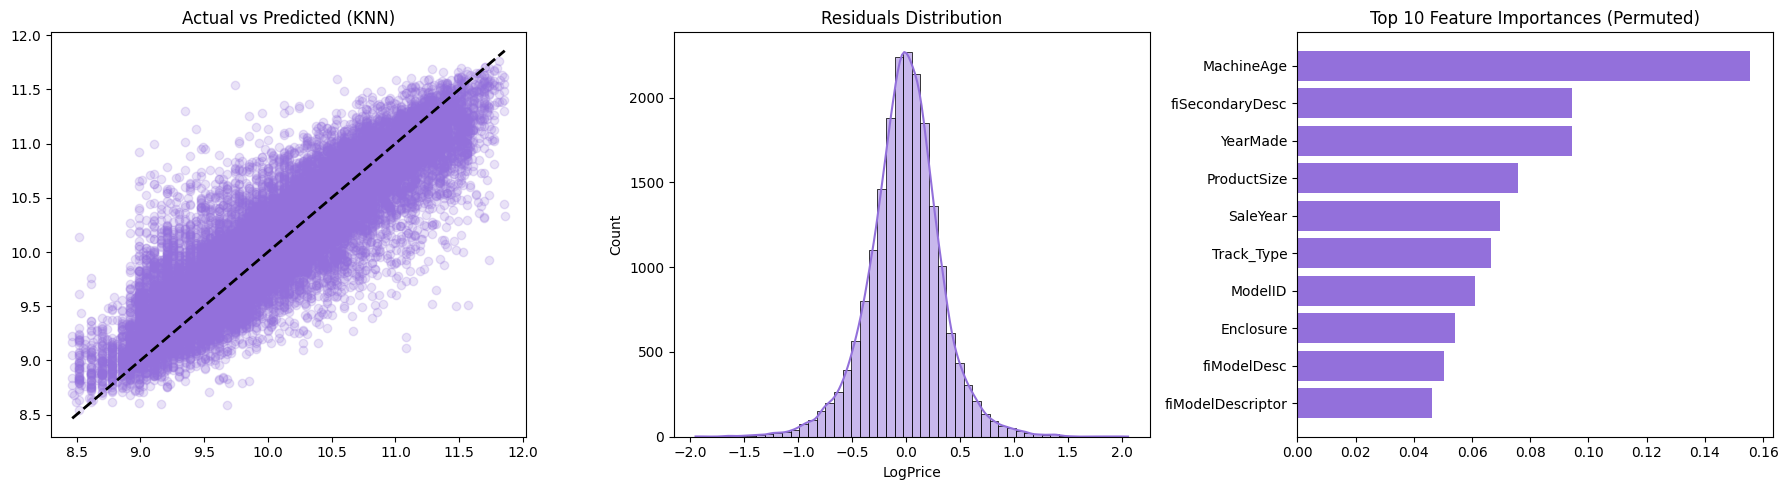

In [ ]:
"""
Group 2
Obil Nathaniel - 271048001
Muhammad Abdullah - 281134982
"""
# ==========================================
# EXPERIMENT 4: K-NEAREST NEIGHBORS (KNN)
# ==========================================
"""
OVERVIEW: This notebook uses KNN (K-Nearest Neighbors). It predicts prices
by finding the 'K' most similar bulldozers and averaging their prices.

STEPS:
1. DATA SUBSAMPLING: Used 100,000 rows to balance memory usage and accuracy.
2. DATA SCALING: Essential for KNN. We use StandardScaler so that large
   feature values (like ID numbers) don't dominate small ones (like Age).
3. LEAK-PROOF IMPUTATION: Filling missing values based on training-set medians.
4. PERMUTATION IMPORTANCE: Because KNN is a distance-based "black box" without
   native feature logic, we calculate 'Permutation Importance' to determine
   which features influence the distance metric the most.

GOAL: To observe how a distance-based similarity model performs compared
      to tree-based models.
"""

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# ----------------------------
# 1. Mount & Load
# ----------------------------
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ML/TrainAndValid.csv'
df = pd.read_csv(file_path, low_memory=False)

# ----------------------------
# 2. Preprocessing & Subsampling
# ----------------------------
df = df.sample(n=100000, random_state=42)

df['LogPrice'] = np.log(df['SalePrice'])
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear'] = df['saledate'].dt.year
df['YearMade'] = df['YearMade'].replace(1000, np.nan)
df['MachineAge'] = df['SaleYear'] - df['YearMade']
df.drop('saledate', axis=1, inplace=True)

# ----------------------------
# 3. Encoding & Missing Values
# ----------------------------
for label, content in df.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        df[label] = content.astype("category").cat.codes + 1

X = df.drop(['SalePrice', 'LogPrice'], axis=1)
y = df['LogPrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute
for label, content in X_train.items():
    if pd.api.types.is_numeric_dtype(content):
        mid = content.median()
        X_train[label] = X_train[label].fillna(mid)
        X_test[label] = X_test[label].fillna(mid)

# KNN REQUIRES SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------
# 4. Modeling (KNN)
# ----------------------------
print("Training KNN on 100,000 samples... this will take a moment.")
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# ----------------------------
# 5. Evaluation
# ----------------------------
y_pred = knn.predict(X_test_scaled)

print("\n===== KNN PERFORMANCE =====")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

# ----------------------------
# 6. Visualizations
# ----------------------------
plt.figure(figsize=(18, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.2, color='mediumpurple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs Predicted (KNN)")

# Plot 2: Residuals Distribution
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, bins=50, kde=True, color='mediumpurple')
plt.title("Residuals Distribution")

# Plot 3: Permutation Feature Importance
print("Calculating Permutation Importance for visualization...")
plt.subplot(1, 3, 3)
perm_importance = permutation_importance(knn, X_test_scaled[:2000], y_test[:2000],
                                         n_repeats=3, random_state=42, n_jobs=-1)

# Extract top 10 features
sorted_idx = perm_importance.importances_mean.argsort()[-10:]
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx], color='mediumpurple')
plt.title("Top 10 Feature Importances (Permuted)")

plt.tight_layout()
plt.show()